# Análisis de Clustering RFM de Clientes de E-commerce

**Objetivo:**
  * Segmentar clientes en diferentes grupos basados en su comportamiento de compra utilizando el análisis RFM (Recency, Frequency, Monetary) y el algoritmo de clustering K-Means.
  * Enriquecer la clusterización anterior usando otras variables (e.j., categóricas) con otros algoritmos como K-Prototypes.
  * Segmentar clientes en base a la ubicación de su residencia en base al algoritmo DBSCAN.
  * Con esto se busca conocer mejor a los clientes y sus hábitos de compra, de cara a permitir que a la empresa dirigir estrategias de marketing más efectivas a cada segmento.

**Dataset**:
  * La información del dataset se encuentra aquí: https://www.kaggle.com/datasets/bytadit/transactional-ecommerce

### Tabla de Clientes
Contiene la información detallada de los usuarios registrados en la aplicación de comercio electrónico.

- **customer_id** = id único del cliente  
- **first_name** = nombre del cliente  
- **last_name** = apellido del cliente  
- **username** = nombre de usuario del cliente  
- **email** = correo electrónico del cliente  
- **gender** = género del cliente (Masculino (M) o Femenino (F))  
- **device_type** = tipo de dispositivo usado por el cliente al usar la app  
- **device_id** = id del dispositivo usado por el cliente en la app  
- **device_version** = versión detallada del dispositivo usado por el cliente  
- **home_location_lat** = latitud de la ubicación del cliente  
- **home_location_long** = longitud de la ubicación del cliente  
- **home_location** = provincia/región del cliente  
- **home_country** = país del cliente  
- **first_join_date** = fecha de registro inicial del cliente en la app  

---

### Tabla de Productos
Contiene los datos detallados de los productos (moda) vendidos en la aplicación.

- **id** = id del producto  
- **gender** = productos orientados/destinados según género  
- **masterCategory** = categoría principal del producto  
- **subCategory** = subcategoría del producto  
- **articleType** = tipo de producto de moda  
- **baseColour** = color base del producto de moda  
- **season** = productos orientados/destinados según temporada  
- **year** = año de producción  
- **usage** = tipo de uso del producto  
- **productDisplayName** = nombre de visualización del producto en la app  

---

### Tabla de Transacciones
Contiene los datos de cada transacción/pedido realizado por el cliente.  
Cada cliente puede hacer múltiples compras de múltiples productos.

- **created_at** = marca de tiempo en que se creó el dato/transacción  
- **customer_id** = id único de cada cliente  
- **booking_id** = id único de la transacción  
- **session_id** = id de sesión único del usuario al visitar la app  
- **product_metadata** = metadatos del producto comprado  
- **payment_method** = método de pago usado en la transacción  
- **payment_status** = estado del pago (Éxito / Fallido)  
- **promo_amount** = monto del descuento en cada transacción  
- **promo_code** = código promocional  
- **shipment_fee** = coste de envío de la transacción (ongkir)  
- **shipment_date_limit** = fecha límite de envío  
- **shipment_location_lat** = latitud de la ubicación/destino del envío  
- **shipment_location_long** = longitud de la ubicación/destino del envío  
- **total_amount** = monto total a pagar en cada transacción  


### Notas:
- Por simplicidad, no vamos a usar los datos de Click Stream

## 0. Carga de Librerías y Definir funciones comunes

In [13]:
!pip install kmodes==0.12.2 nbformat>=4.2.0


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\david.suarez\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import ast
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from kmodes.kprototypes import KPrototypes
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings('ignore')

### 0.1 Funciones comunes

* Aquí puedes incluir las funciones comunes que uses en el código de cara a reutilizarlas cuando lo necesites.

In [15]:
# Function to perform KMeans clustering and calculate silhouette scores and elbow scores
def find_optimal_k(data, min_k=2, max_k=10):
    """
    Finds the optimal number of clusters (K) for K-Means clustering using silhouette scores and elbow method.

    The function iterates over a range of K values from 2 to `max_k`, performs K-Means clustering
    for each K, and calculates the silhouette score to evaluate the clustering quality. The optimal
    K is determined as the one with the highest silhouette score, and a plot of the silhouette
    scores for each K is generated. Additionally, the elbow method is used to plot the sum of squared
    distances for each K.

    Parameters:
    ----------
    data : array-like, shape (n_samples, n_features)
        The dataset to be clustered, typically scaled, with rows representing samples and columns
        representing features.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to consider when evaluating the silhouette score.
        The function will compute silhouette scores for values of K ranging from 2 to `max_k`.

    Returns:
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes:
    -----
    - The silhouette score measures how well clusters are defined. A higher score indicates that
      clusters are well-separated.
    - A plot of silhouette scores versus K values is displayed to visualize the performance of
      different K values.
    - The elbow method is used to plot the sum of squared distances for each K value.

    Example:
    --------
    >>> find_optimal_k(data_scaled, max_k=10)
    """

    silhouette_scores = []
    sse = []
    K_values = range(min_k, max_k + 1)

    # Try different values of K (number of clusters)
    for K in K_values:
        print(f"Training model for K={K}")
        kmeans_model = KMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            algorithm='lloyd',
            random_state=42
            )
        kmeans_model.fit(data)
        cluster_labels = kmeans_model.labels_
        silhouette_avg = silhouette_score(data, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        sse.append(kmeans_model.inertia_)

    # Find the optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Silhouette Score for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)

    # Plot elbow scores for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Elbow Method for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Sum of Squared Distances')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")

    return optimal_k

In [16]:
def find_optimal_k_kprototypes(data, cat_idx: list, min_k=2, max_k=10, n_jobs=-1):
    """
    Finds the optimal number of clusters (K) for K-Prototypes clustering
    using silhouette scores and the elbow method. Parallelized with joblib.

    Parameters
    ----------
    data : array-like of shape (n_samples, n_features)
        The dataset to be clustered. Must contain both numerical and categorical features.
        Rows represent samples and columns represent features.

    cat_idx : list of int
        List of indices corresponding to categorical columns in `data`.

    min_k : int, optional (default=2)
        The minimum number of clusters (K) to evaluate.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to evaluate.

    n_jobs : int, optional (default=-1)
        Number of parallel jobs. -1 means using all available cores.

    Returns
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes
    -----
    - The silhouette score measures how well clusters are separated.
      A higher score indicates more cohesive and distinct clusters.
    - The elbow method is based on the K-Prototypes cost function (`cost_`),
      which is analogous to inertia in KMeans. It reflects the sum of
      dissimilarities (numerical + categorical) between points and their
      assigned cluster centroids.
    - The function produces two plots:
        * Silhouette Score vs. K values
        * Cost (inertia) vs. K values (Elbow Method)
    - Use both plots to determine the most meaningful K:
      the silhouette score identifies well-separated clusters,
      while the elbow plot helps detect diminishing returns.

    Example
    -------
    >>> optimal_k = find_optimal_k_kprototypes(data, cat_idx=[0, 2, 5], max_k=8)
    >>> print(optimal_k)
    4
    """

    # Extraer solo columnas numéricas para silhouette_score
    num_idx = [i for i in range(data.shape[1]) if i not in cat_idx]
    data_num = np.array(data[:, num_idx], dtype=float)

    def evaluate_k(K):
        """Train KPrototypes for a given K and compute silhouette + cost."""
        print(f"Training model for K={K}")
        kproto = KPrototypes(n_clusters=K, init='Huang', n_init=5, random_state=42)
        clusters = kproto.fit_predict(data, categorical=cat_idx)
        silhouette_avg = silhouette_score(data_num, clusters)
        return silhouette_avg, kproto.cost_

    # Run clustering in parallel for each K
    results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_k)(K) for K in range(min_k, max_k + 1)
    )

    # Unpack results
    silhouette_scores, sse = zip(*results)
    K_values = list(range(min_k, max_k + 1))

    # Find optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Silhouette Score for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)

    # Plot elbow scores (cost) for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Elbow Method for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Clustering Cost (Inertia)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")
    return optimal_k

In [17]:
# Función para parsear product_metadata
def parse_product_metadata(metadata_str):
    try:
        items = ast.literal_eval(metadata_str)
        product_ids = [item['product_id'] for item in items]
        quantities  = [item['quantity'] for item in items]
        item_price  = [item['item_price'] for item in items]
        total_quantity = sum(quantities)
        total_price    = sum(item_price)
        return product_ids, total_quantity, total_price, len(items)
    except:
        return [], 0, 0, 0

## 1. Cargar datos

In [18]:
# Cargamos los datos de transacciones, clientes y productos
# El archivo de productos no se usará directamente análisis como el de RFM, pero se carga para una exploración inicial

transactions = pd.read_csv('transactions.csv', quoting=1, on_bad_lines='skip')
customers = pd.read_csv('customer.csv')
products = pd.read_csv('product.csv', on_bad_lines='skip')
print('Datasets cargados correctamente.')
print(f'Transacciones: {transactions.shape}')
print(f'Clientes: {customers.shape}')
print(f'Productos: {products.shape}')

Datasets cargados correctamente.
Transacciones: (852584, 14)
Clientes: (100000, 15)
Productos: (44424, 10)


In [19]:
print("================ Transactions ================")
display(transactions.head(2))
print("================ Customers ================")
display(customers.head(2))
print("================ Products ================")
display(products.head(2))

================ Transactions ================


,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29T15:22:01.458193Z,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03T05:07:24.812676Z,-8.227893,111.969107,199832
1,2018-07-30T12:40:22.365620Z,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03T01:29:03.415705Z,3.013470,107.802514,155526


================ Customers ================


,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.043345,101.360523,Sumatera Barat,Indonesia,2019-07-21
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.212489,106.818850,Jakarta Raya,Indonesia,2017-07-16


================ Products ================


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans


## 2. Preprocesamiento y Creación de Features RFM

In [20]:
%%time
# Procesamiento inicial
df = transactions.copy()
df['created_at'] = pd.to_datetime(df['created_at'])

print(f"Transacciones: {len(df):,}")

# Parsear metadata de productos
print("Parseando metadata de productos...")
parsed_data = df['product_metadata'].apply(lambda x: pd.Series(parse_product_metadata(x)))
df['product_ids']    = parsed_data[0]
df['total_quantity'] = parsed_data[1]
df['total_price']    = parsed_data[2]
df['num_items']      = parsed_data[3]

print("Parsing completado.")

Transacciones: 852,584
Parseando metadata de productos...
Parsing completado.
CPU times: total: 2min 10s
Wall time: 2min 15s


In [21]:
df.head()

,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount,product_ids,total_quantity,total_price,num_items
0,2018-07-29 15:22:01.458193+00:00,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03T05:07:24.812676Z,-8.227893,111.969107,199832,[54728],1,191247,1
1,2018-07-30 12:40:22.365620+00:00,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03T01:29:03.415705Z,3.013470,107.802514,155526,[16193],1,145526,1
2,2018-09-15 11:51:17.365620+00:00,4774,6000fffb-9c1a-4f4a-9296-bc8f6b622b50,93325fb6-eb00-4268-bb0e-6471795a0ad0,"[{'product_id': 53686, 'quantity': 4, 'item_pr...",OVO,Success,0,NaN,10000,2018-09-18T08:41:49.422380Z,-2.579428,115.743885,550696,[53686],4,135174,1
3,2018-11-01 11:23:48.365620+00:00,4774,f5e530a7-4350-4cd1-a3bc-525b5037bcab,bcad5a61-1b67-448d-8ff4-781d67bc56e4,"[{'product_id': 20228, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-11-05T17:42:27.954235Z,-3.602334,120.363824,271012,[20228],1,271012,1
4,2018-12-18 11:20:30.365620+00:00,4774,0efc0594-dbbf-4f9a-b0b0-a488cfddf8a2,df1042ab-13e6-4072-b9d2-64a81974c51a,"[{'product_id': 55220, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,0,2018-12-23T17:24:07.361785Z,-3.602334,120.363824,198753,[55220],1,198753,1


#### PREGUNTA 1:
* ¿Cómo calculamos las variables RFM en base a los datos disponibles?

#### RESPUESTA:

Las variables RFM se construyen a nivel de cliente a partir de la tabla de transacciones:

- **Recency**: días transcurridos desde la última compra del cliente hasta una fecha de referencia, para la cual se tomará la fecha máxima del dataset.
- **Frequency**: regularidad con la que el cliente compra en un periodo de tiempo. En este caso se puede medir con el conteo de booking_id únicos.
- **Monetary**: gasto acumulado del cliente, calculado como la suma de total_amount, que es la cantidad que paga el cliente en cada transacción tras promociones excluyendo los gastos de envío, ya que lo interesante de este estudio es calcular cuánto gastan los clientes en productos, no en gastos logísticos 

Para que la métrica represente compras reales, se calculan solo sobre transacciones con payment_status = 'Success'.

In [22]:
rfm_df = df[df['payment_status'] == 'Success'].copy() # Nos quedamos solo con compras exitosas, que son las que se han consolidado

max_date = rfm_df['created_at'].max() # Fecha de referencia para medir recencia

rfm_df['net_amount'] = rfm_df['total_amount'] - rfm_df['shipment_fee'] # Para saber el gasto neto en cada trnasacción, excluyendo los gastos de envío

rfm = rfm_df.groupby('customer_id').agg( # Se agrupa por cliente para calcular sus métricas
        Recency=('created_at', lambda dates: (max_date - dates.max()).days), # Días desde la última compra exitosa
        Frequency=('booking_id', 'nunique'), # Número de compras exitosas
        Monetary=('net_amount', 'sum') # Suma total de las cantidades gastadas por el cliente, excluyendo los gastos de envío
    )


rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
3,35,49,20551374
8,77,7,3853561
9,64,6,2603665
11,146,1,182533
15,207,5,2084870


#### PREGUNTA 2:
* Realiza un análisis exploratorio de datos de las variables RFM. ¿Es necesario realizar alguna transformación sobre ellas para usarlas en clustering?

#### RESPUESTA

Sí, es necesario transformar las variables RFM antes de aplicar clustering (especialmente para K-Means). En el EDA normalmente se observa asimetría positiva, aún más acusada en Frequency y Monetary (colas largas por clientes de alto valor). Recency, Frequency y Monetary están en escalas muy distintas, por lo que sin escalar dominaría la variable con mayor magnitud. Además, suelen aparecer outliers que pueden sesgar los centroides.

Por ello, la recomendación es:

1. Aplicar una transformación de estabilización como log1p sobre variables sesgadas (Frequency, Monetary y Recency).
2. Escalar las variables con RobustScaler para que los outliers afecten lo menos posible.
3. Usar las variables transformadas para el clustering y conservar el RFM original para interpretación de negocio.

Estadísticos y skewness antes de transformaciones:


,count,mean,std,min,25%,50%,75%,max
Recency,50242.0,2.996049e+02,4.344302e+02,0.0,39.00,111.0,361.0,2221.0
Frequency,50242.0,1.624068e+01,2.866349e+01,1.0,2.00,6.0,17.0,550.0
Monetary,50242.0,8.787403e+06,1.583045e+07,21270.0,751276.75,2954328.0,9677650.5,315431849.0


Recency      2.263723
Frequency    4.578551
Monetary     4.510350
dtype: float64

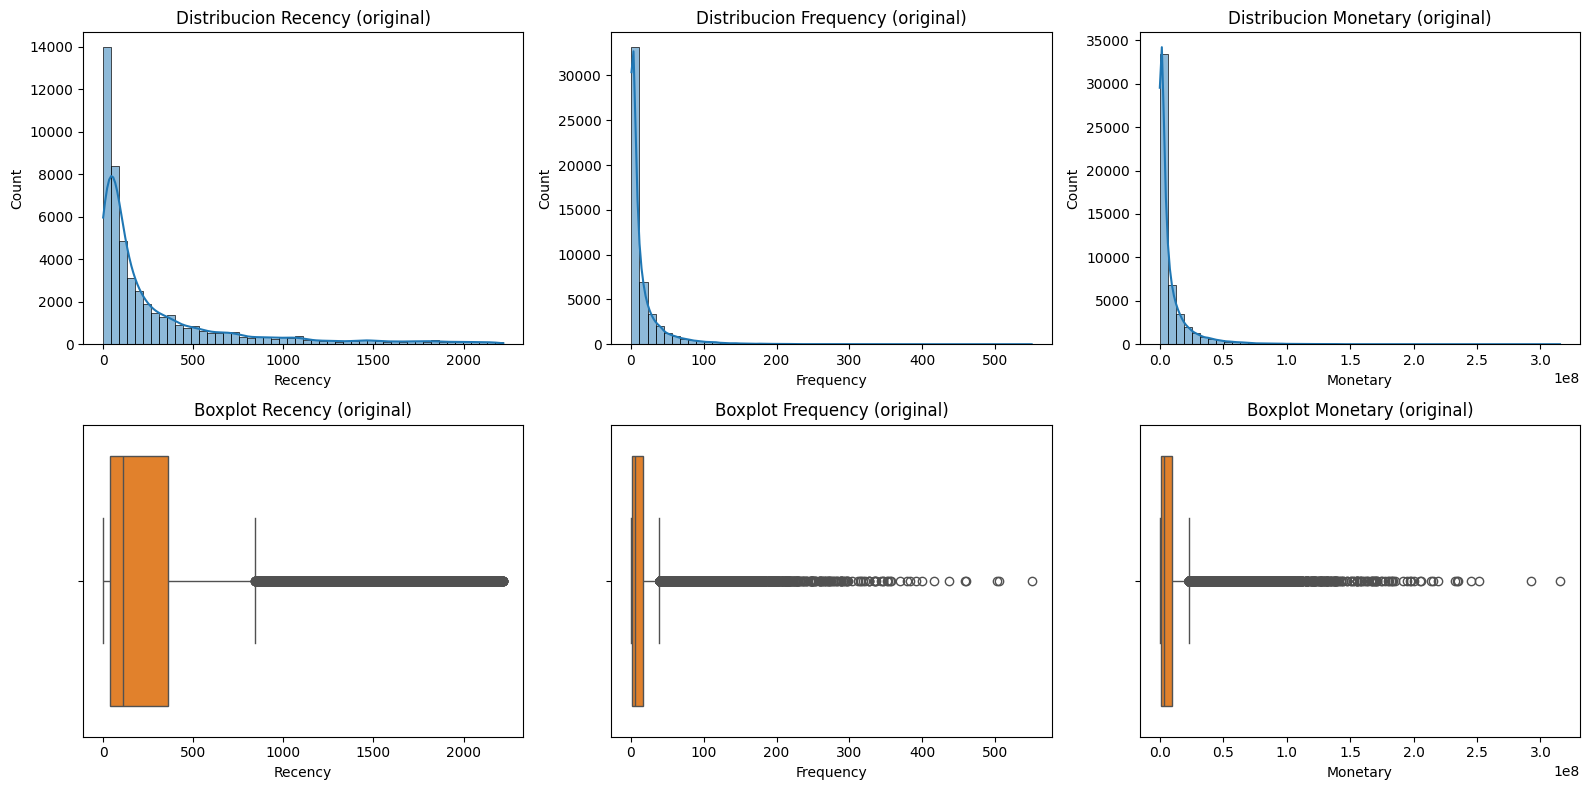


Estadísticos y skewness después de transformaciones:


Recency     -0.356024
Frequency    0.580517
Monetary    -0.035287
dtype: float64

,count,mean,std,min,25%,50%,75%,max
Recency,50242.0,-0.004873,0.714978,-2.142080,-0.467421,0.000000e+00,0.532579,1.356325
Frequency,50242.0,0.077563,0.650811,-0.699180,-0.472886,0.000000e+00,0.527114,2.436613
Monetary,50242.0,-0.028130,0.641864,-1.930387,-0.535743,3.475147e-16,0.464257,1.827480


In [23]:
cols = ['Recency', 'Frequency', 'Monetary']

print("Estadísticos y skewness antes de transformaciones:")

display(rfm[cols].describe().T) # Estadísticos de cada una de las variables RFM

skewness = rfm[cols].skew() # Asimetría para verificar sesgo
display(skewness)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(cols):
    sns.histplot(rfm[col], bins=50, kde=True, ax=axes[0, i], color='#1f77b4') # Visualización de hisotgramas para cada variable RFM para ver la distribución y el sesgo de los datos
    axes[0, i].set_title(f'Distribucion {col} (original)')
    sns.boxplot(x=rfm[col], ax=axes[1, i], color='#ff7f0e')
    axes[1, i].set_title(f'Boxplot {col} (original)')

plt.tight_layout()
plt.show()

rfm_log = rfm[cols].copy()
rfm_log[cols] = np.log1p(rfm_log[cols]) # Transformación log para reducir sesgo en clustering

scaler = RobustScaler()
rfm_scaled = scaler.fit_transform(rfm_log) # Normalización RobustScaler para reducir el impacto de outliers en el clustering
rfm_scaled = pd.DataFrame(rfm_scaled, columns=cols)

print("\nEstadísticos y skewness después de transformaciones:")

display(rfm_log[cols].skew())
display(rfm_scaled.describe().T)

## 3. Clustering con K-Means

#### PREGUNTA 3:
* Realiza una clusterización con K-Means sobre los datos de RFM calculados previamente

#### RESPUESTA:

Se aplica K-Means sobre las variables RFM previamente transformadas con log1p y escaladas con RobustScaler, porque K-Means trabaja con distancias y es sensible tanto a diferencias de escala como a outliers.

Antes de buscar el K óptimo conviene acotar un rango razonable según los resultados esperados. En este contexto, K = 2 tiene sentido como punto de partida, porque una primera segmentación natural suele separar clientes de mayor valor y actividad frente a clientes de menor valor o más inactivos. Sin embargo, quedarse solo con dos grupos puede ser demasiado grueso si queremos distinguir, por ejemplo, clientes muy valiosos, clientes frecuentes pero de ticket medio, clientes recientes con potencial y clientes próximos al abandono.

Por ello, se evalúa un rango K entre 2 y 6:

1. K=2 aporta una segmentación básica y fácilmente accionable.
2. Valores entre 3 y 5 suelen permitir segmentos más útiles para marketing sin perder interpretabilidad.
3. Valores por encima de 6 empiezan a ser menos prácticos de operar y más difíciles de justificar con una estrategia comercial diferenciada.

Dentro de ese rango, la elección final se apoya en métricas cuantitativas como silhouette score y el método del codo, pero restringiendo la búsqueda a soluciones que tengan sentido desde la perspectiva del objetivo del estudio. Después se entrena el modelo final y se analizan los centroides en términos del RFM original para interpretar cada segmento.

Training model for K=2


Training model for K=3
Training model for K=4
Training model for K=5
Training model for K=6


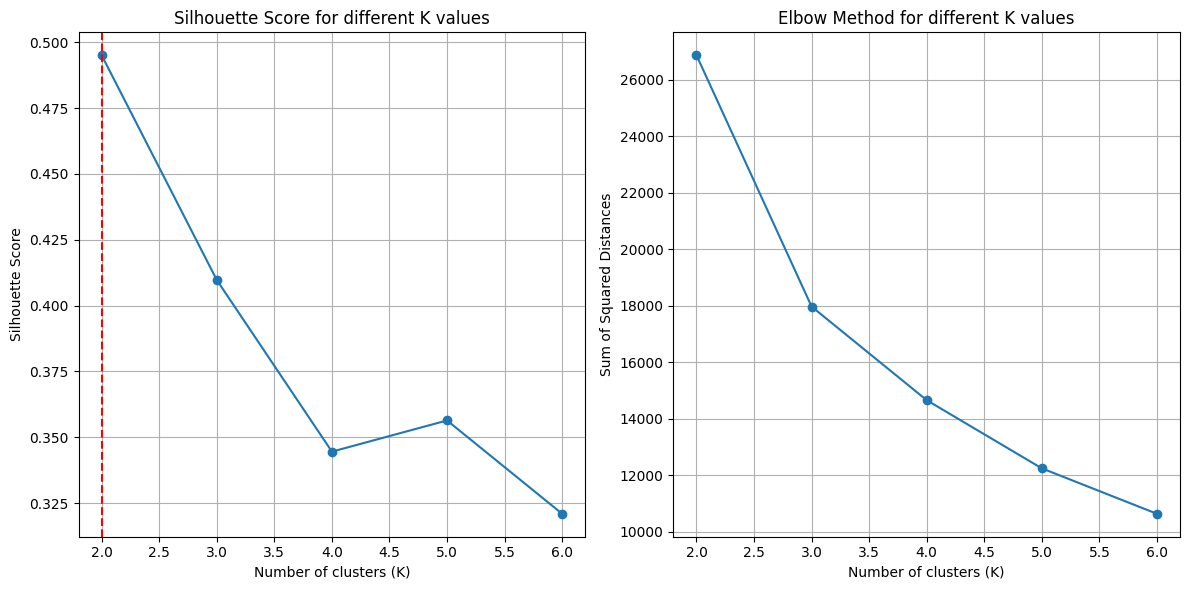

Optimal number of clusters: 2


In [24]:
optimal_k = find_optimal_k(rfm_scaled, min_k=2, max_k=6) # Se evalua un rango acotado y accionable desde negocio

kmeans_rfm = KMeans(n_clusters=optimal_k, random_state=42) # Entrenamiento final de K-Means

rfm_clustered = rfm.copy()
rfm_clustered['Cluster'] = kmeans_rfm.fit_predict(rfm_scaled) # Columna con el cluster asignado a cada cliente tras aplicar K-Means

#### PREGUNTA 4:
* ¿Qué interpretación haces de los resultados obtenidos con la clusterización? ¿Qué acciones propondrías hacer sobre ellos?

#### RESPUESTA:

Con base en las estadísticas por clúster y las tres gráficas (Frequency-Monetary, Frequency-Recency y Monetary-Recency), la interpretación es consistente y robusta:

- **Cluster 0 (23,767 clientes)** representa clientes **activos y de alto valor**.
  Recency media: **50.05** días (mediana **39**).
  Frequency media: **31.30** compras (mediana **19**).
  Monetary medio: **17,082,950** (mediana **10,355,051**).

- **Cluster 1 (26,475 clientes)** representa clientes **de bajo compromiso / inactivos**.
  Recency media: **523.63** días (mediana **337**).
  Frequency media: **2.72** compras (mediana **2**).
  Monetary medio: **1,340,366** (mediana **834,117**).

Lo que muestran las gráficas:

- En **Frequency vs Recency**, el Cluster 0 se concentra en zonas de **mayor frecuencia y menor recencia**, mientras el Cluster 1 queda en **baja frecuencia y alta recencia**.
- En **Monetary vs Recency**, se ve una separación clara: Cluster 0 con **más gasto y menor recencia**, Cluster 1 con **menor gasto y mayor recencia**.
- En **Frequency vs Monetary**, ambos ejes crecen juntos y el Cluster 0 domina los valores altos, confirmando su mayor valor económico.

Conclusión de negocio: el modelo con K=2 está capturando una frontera muy útil entre **clientes valiosos y activos** vs **clientes fríos o con riesgo de abandono**.

Acciones recomendadas:

1. **Cluster 0**: fidelización avanzada (VIP), cross-sell/up-sell, recompensas por recurrencia y campañas de retención premium.
2. **Cluster 1**: reactivación (win-back), incentivos al retorno, automatizaciones por inactividad y ofertas de bajo umbral para recuperar frecuencia.

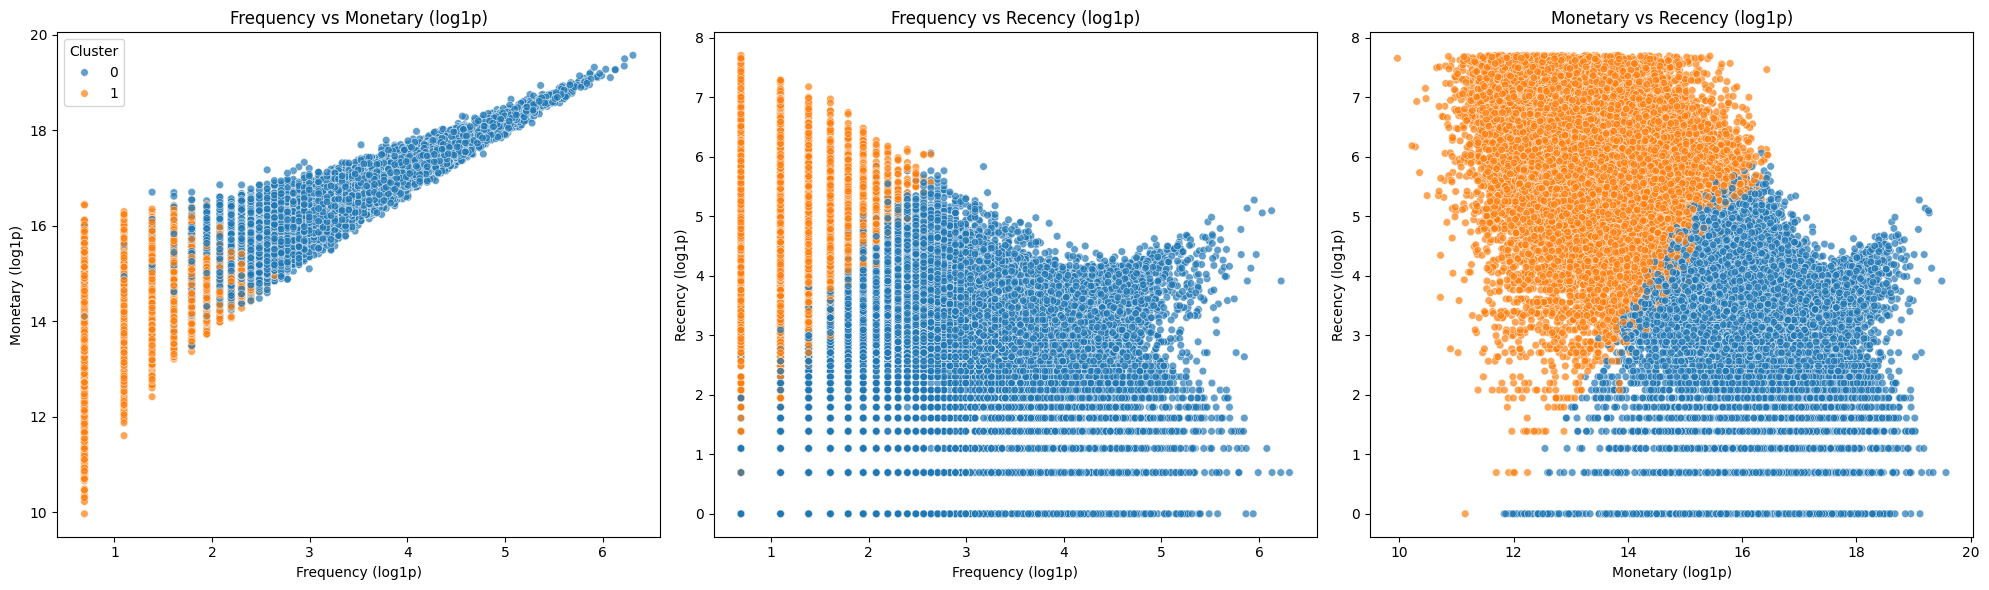

,customers,recency_mean,frequency_mean,monetary_mean,recency_median,frequency_median,monetary_median
Cluster,,,,,,,
0,23767,50.05,31.30,17082950.40,39.0,19.0,10355051.0
1,26475,523.63,2.72,1340366.27,337.0,2.0,834117.0


,customers,recency_mean,frequency_mean,monetary_mean,recency_median,frequency_median,monetary_median
Cluster,,,,,,,
0,23767,50.05,31.30,17082950.40,39.0,19.0,10355051.0
1,26475,523.63,2.72,1340366.27,337.0,2.0,834117.0


,Cluster,segment_name,recommended_action
0,0,Alto valor y activos,"Fidelizacion, cross-sell, beneficios VIP y rec..."
1,1,Bajo valor o inactivos,"Reactivacion, cupones de retorno y campañas de..."


In [25]:
rfm_plot = rfm_clustered.copy()
rfm_plot['Recency_log'] = rfm_log['Recency'].values
rfm_plot['Frequency_log'] = rfm_log['Frequency'].values
rfm_plot['Monetary_log'] = rfm_log['Monetary'].values

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot( # Scatter plot de Frequency vs Monetary con colores por cluster
    data=rfm_plot,
    x='Frequency_log',
    y='Monetary_log',
    hue='Cluster',
    palette='tab10',
    alpha=0.7,
    s=30,
    ax=axes[0]
 )
axes[0].set_title('Frequency vs Monetary (log1p)')
axes[0].set_xlabel('Frequency (log1p)')
axes[0].set_ylabel('Monetary (log1p)')

sns.scatterplot( # Scatter plot de Frequency vs Recency con colores por cluster
    data=rfm_plot,
    x='Frequency_log',
    y='Recency_log',
    hue='Cluster',
    palette='tab10',
    alpha=0.7,
    s=30,
    ax=axes[1],
    legend=False
 )
axes[1].set_title('Frequency vs Recency (log1p)')
axes[1].set_xlabel('Frequency (log1p)')
axes[1].set_ylabel('Recency (log1p)')

sns.scatterplot( # Scatter plot de Monetary vs Recency con colores por cluster
    data=rfm_plot,
    x='Monetary_log',
    y='Recency_log',
    hue='Cluster',
    palette='tab10',
    alpha=0.7,
    s=30,
    ax=axes[2],
    legend=False
 )
axes[2].set_title('Monetary vs Recency (log1p)')
axes[2].set_xlabel('Monetary (log1p)')
axes[2].set_ylabel('Recency (log1p)')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title='Cluster')

plt.tight_layout()
plt.show()


cluster_summary = ( # Resumen por cluster en escala original
    rfm_clustered
    .groupby('Cluster')
    .agg(
        customers=('Recency', 'size'),
        recency_mean=('Recency', 'mean'),
        frequency_mean=('Frequency', 'mean'),
        monetary_mean=('Monetary', 'mean'),
        recency_median=('Recency', 'median'),
        frequency_median=('Frequency', 'median'),
        monetary_median=('Monetary', 'median')
    )
    .sort_values('monetary_mean', ascending=False)
 )

display(cluster_summary.round(2))

cluster_actions = pd.DataFrame({ # Conclusiones y acciones recomendadas para cada cluster, basadas en su comportamiento RFM
    'Cluster': [0, 1],
    'segment_name': ['Alto valor y activos', 'Bajo valor o inactivos'],
    'recommended_action': [
        'Fidelizacion, cross-sell, beneficios VIP y recomendaciones personalizadas',
        'Reactivacion, cupones de retorno y campañas de win-back'
    ]
})

display(cluster_summary.round(2))
display(cluster_actions)

## 4. Consideración de variables adicionales sobre los clientes

In [26]:
# Procesamiento de variables asociadas a los clientes
max_join_date = str(customers['first_join_date'].max())
print(max_join_date)
customers['first_join_date'] = pd.to_datetime(customers['first_join_date'])
customers['age'] = int(max_join_date[:4]) - pd.to_datetime(customers['birthdate']).dt.year

# Tiempo que un cliente ha permanecido activo con la empresa desde la fecha en que se unió por primera vez.
customers['tenure_days'] = (pd.to_datetime(max_join_date) - customers['first_join_date']).dt.days
display(customers.head(2))

2022-07-31


,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date,age,tenure_days
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.043345,101.360523,Sumatera Barat,Indonesia,2019-07-21,26,1106
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.212489,106.818850,Jakarta Raya,Indonesia,2017-07-16,29,1841


#### PREGUNTA 5:
* Realiza un análisis exploratorio de las demás variables de clientes, y relaciónalas con la tabla de transacciones.
* ¿Es necesario realizar algún tipo de transformación sobre estas nuevas variables para hacer clustering con ellas?

#### RESPUESTA:

**P1**: Las variables adicionales de clientes aportan contexto demográfico, tecnológico y territorial que el RFM no captura. En el EDA se observa que:

- age y tenure_days describen el ciclo de vida del cliente.
- device_type y gender ayudan a detectar patrones de uso y afinidad.
- home_location aporta una dimensión territorial útil para campañas locales.
- Al relacionarlas con las métricas transaccionales (Recency, Frequency, Monetary, avg_ticket) se puede ver qué perfiles compran más, gastan más o permanecen más tiempo activos.

**P2**: Sí, es necesario transformar estas variables para clustering:

1. Las variables numéricas (avg_ticket, tenure_days) presentan sesgo positivo y outliers, por lo que conviene aplicar log1p para estabilizar la distribución.
2. Todas las variables numéricas deben escalarse (con RobustScaler) para que ninguna domine la distancia.
3. Las variables categóricas (gender, device_type, home_location) no pueden tratarse con K-Means directamente; requieren una técnica para datos mixtos como K-Prototypes.

In [27]:
customers_df = pd.merge(rfm, customers[['customer_id', 'age', 'tenure_days', 'gender', 'device_type', 'home_location']], on='customer_id', how='left')
customers_df['avg_ticket'] = customers_df['Monetary'] / customers_df['Frequency'] # Ticket promedio por cliente
display(customers_df.head())  # Construcción de dataset con variables adicionales de comportamiento de compra por cliente para enriquecer el clustering

numeric_vars = ['age', 'tenure_days', 'avg_ticket', 'Recency', 'Frequency', 'Monetary']
categoric_vars = ['gender', 'device_type', 'home_location']

print("=== Estadísticos descriptivos (numéricas) ===")
display(customers_df[numeric_vars].describe().T)

print("\n=== Estadísticos descriptivos (categóricas) ===")
display(customers_df[categoric_vars].astype(str).describe().T)

print("\n=== Asimetría (skewness) ===")
display(customers_df[numeric_vars].skew().rename('skewness').to_frame())

print("\n=== Top 10 ubicaciones por número de clientes ===")
top_locations = (
    customers_df
    .groupby('home_location')
    .agg(
        n_customers=('customer_id', 'count'),
        avg_orders=('Frequency', 'mean'),
        avg_revenue=('Monetary', 'mean')
    )
    .sort_values('n_customers', ascending=False)
    .head(10)
    .round(2)
)
display(top_locations)

# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(customers_df['age'], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de age')

sns.histplot(customers_df['tenure_days'], bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribución de tenure_days')

sns.histplot(customers_df['Frequency'], bins=40, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Distribución de Frequency')

sns.boxplot(data=customers_df, x='device_type', y='Monetary', ax=axes[1, 0])
axes[1, 0].set_title('Revenue por dispositivo')

sns.boxplot(data=customers_df, x='gender', y='avg_ticket', ax=axes[1, 1])
axes[1, 1].set_title('Ticket promedio por género')

sns.histplot(customers_df['Monetary'], bins=40, kde=True, ax=axes[1, 2])
axes[1, 2].set_title('Distribución de Monetary')

plt.tight_layout()
plt.show()

print("\n=== Transformaciones aplicadas ===")

customer_cluster_base = customers_df[numeric_vars + categoric_vars + ['customer_id']].copy()
customer_cluster_base[numeric_vars] = customer_cluster_base[numeric_vars].fillna(0)
customer_cluster_base[categoric_vars] = customer_cluster_base[categoric_vars].fillna('Unknown').astype(str) # Transformaciones necesarias para clustering

for col in numeric_vars:
    customer_cluster_base[col] = np.log1p(customer_cluster_base[col].clip(lower=0)) # log1p para reducir sesgo en variables con asimetría alta

scaler = RobustScaler() # Escalado de variables numéricas
scaled_cols = [f'{col}_scaled' for col in numeric_vars]
customer_cluster_base[scaled_cols] = scaler.fit_transform(customer_cluster_base[numeric_vars])
customer_cluster_base.drop(columns=numeric_vars, inplace=True)

print("Skewness después de log1p + escalado:")
display(customer_cluster_base[scaled_cols].skew().round(3).to_frame('skewness_post'))
print("\nBase lista para clustering (primeras filas):")
display(customer_cluster_base.head())

,customer_id,Recency,Frequency,Monetary,age,tenure_days,gender,device_type,home_location,avg_ticket
0,3,35,49,20551374,36,1436,M,Android,Jakarta Raya,419415.795918
1,8,77,7,3853561,22,533,F,Android,Sulawesi Utara,550508.714286
2,9,64,6,2603665,16,400,F,Android,Jakarta Raya,433944.166667
3,11,146,1,182533,29,147,M,Android,Kalimantan Timur,182533.000000
4,15,207,5,2084870,39,1037,F,Android,Jawa Barat,416974.000000


=== Estadísticos descriptivos (numéricas) ===


,count,mean,std,min,25%,50%,75%,max
age,50242.0,2.651761e+01,7.267229e+00,6.0,21.00,2.600000e+01,3.100000e+01,68.0
tenure_days,50242.0,9.820416e+02,6.201171e+02,0.0,418.00,9.150000e+02,1.484000e+03,2222.0
avg_ticket,50242.0,5.396937e+05,4.601119e+05,21270.0,307129.10,4.502918e+05,6.161484e+05,13899505.0
Recency,50242.0,2.996049e+02,4.344302e+02,0.0,39.00,1.110000e+02,3.610000e+02,2221.0
Frequency,50242.0,1.624068e+01,2.866349e+01,1.0,2.00,6.000000e+00,1.700000e+01,550.0
Monetary,50242.0,8.787403e+06,1.583045e+07,21270.0,751276.75,2.954328e+06,9.677650e+06,315431849.0



=== Estadísticos descriptivos (categóricas) ===


,count,unique,top,freq
gender,50242,2,F,32253
device_type,50242,2,Android,38595
home_location,50242,33,Jakarta Raya,9294


...

,n_customers,avg_orders,avg_revenue
home_location,,,
Jakarta Raya,9294,16.15,8753512.98
Jawa Barat,5736,16.91,9160568.11
Jawa Tengah,5547,16.40,8783232.68
Jawa Timur,4885,15.90,8670407.16
Yogyakarta,3974,16.00,8651971.77
Kalimantan Barat,2811,15.73,8428797.71
Lampung,2760,15.70,8525119.02
Kalimantan Tengah,2169,16.42,8798580.99
Kalimantan Selatan,2098,15.92,8627135.91



=== Transformaciones aplicadas ===
Skewness después de log1p + escalado:


,skewness_post
age_scaled,-0.259
tenure_days_scaled,-1.868
avg_ticket_scaled,0.247
Recency_scaled,-0.356
Frequency_scaled,0.581
Monetary_scaled,-0.035



Base lista para clustering (primeras filas):


,gender,device_type,home_location,customer_id,age_scaled,tenure_days_scaled,avg_ticket_scaled,Recency_scaled,Frequency_scaled,Monetary_scaled
0,M,Android,Jakarta Raya,3,0.840904,0.355881,-0.102027,-0.515252,1.097308,0.758924
1,F,Android,Sulawesi Utara,8,-0.427930,-0.426477,0.288626,-0.164244,0.074525,0.103970
2,F,Android,Jakarta Raya,9,-1.234672,-0.652853,-0.053115,-0.247013,0.000000,-0.049437
3,M,Android,Kalimantan Timur,11,0.281191,-1.440611,-1.296952,0.123451,-0.699180,-1.089323
4,F,Android,Jawa Barat,15,1.048971,0.098818,-0.110413,0.281028,-0.086033,-0.136382


#### PREGUNTA 6:
* Justifica qué nuevas variables consideras relevante para la segmentación y, en base a ellas, aplica las técnicas adecuadas de clustering para poder segmentar los datos.

#### RESPUESTA:

Para enriquecer la segmentación se consideran especialmente relevantes estas variables adicionales:

- tenure_days: mide antigüedad y madurez del cliente.
- device_type: puede reflejar comportamiento digital distinto.
- home_location: introduce contexto geográfico y diferencias regionales de demanda.
- age: puede reflejar distintos comportamientos según la edad.

No se incluye gender como variable principal del clustering mixto porque en el EDA mostró menor capacidad de diferenciación que las variables anteriores. Dado que aquí combinamos variables numéricas y categóricas, la técnica adecuada es **K-Prototypes**, que extiende K-Means a datos mixtos. Se construyen segmentos usando variables numéricas transformadas y escaladas junto con variables categóricas sin one-hot encoding.

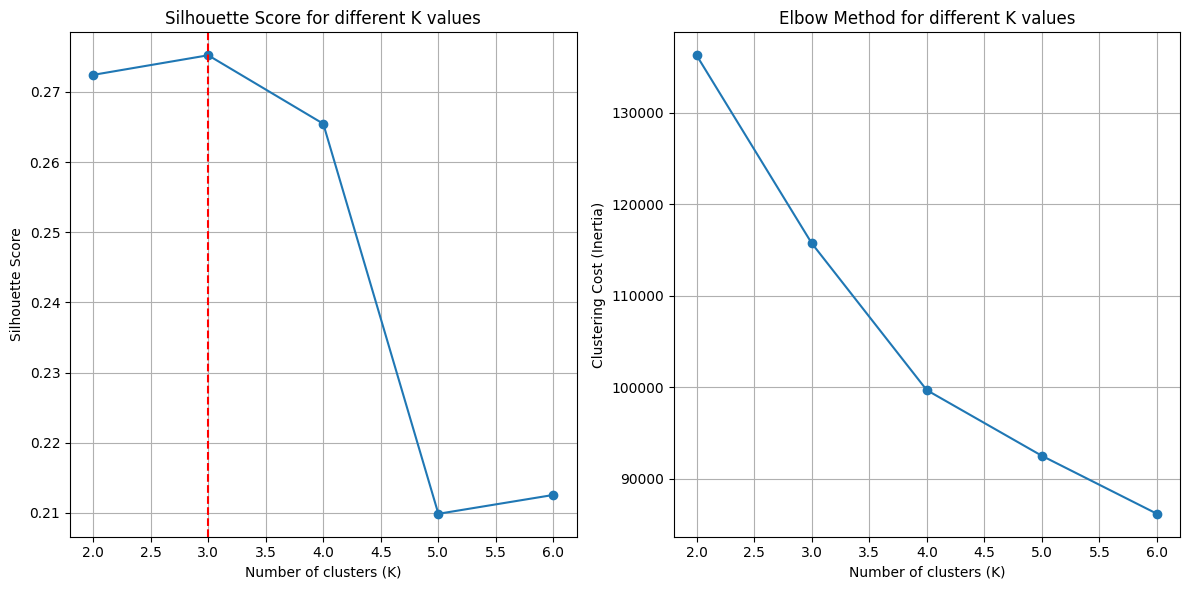

Optimal number of clusters: 3
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/50, moves: 13030, ncost: 116868.09872624256
Run: 1, iteration: 2/50, moves: 4195, ncost: 115816.79429812802
Run: 1, iteration: 3/50, moves: 864, ncost: 115768.14746627375
Run: 1, iteration: 4/50, moves: 270, ncost: 115761.88453856674
Run: 1, iteration: 5/50, moves: 112, ncost: 115760.44491422783
Run: 1, iteration: 6/50, moves: 57, ncost: 115760.07920585622
Run: 1, iteration: 7/50, moves: 40, ncost: 115759.8647485143
Run: 1, iteration: 8/50, moves: 26, ncost: 115759.77107603048
Run: 1, iteration: 9/50, moves: 23, ncost: 115759.70907370775
Run: 1, iteration: 10/50, moves: 22, ncost: 115759.65662409777
Run: 1, iteration: 11/50, moves: 1, ncost: 115759.6559045554
Run: 1, iteration: 12/50, moves: 0, ncost: 115759.6559045554


,age_scaled,tenure_days_scaled,avg_ticket_scaled,Recency_scaled,Frequency_scaled,Monetary_scaled,device_type,home_location,customer_id,cluster
0,0.840904,0.355881,-0.102027,-0.515252,1.097308,0.758924,Android,Jakarta Raya,3,2
1,-0.427930,-0.426477,0.288626,-0.164244,0.074525,0.103970,Android,Sulawesi Utara,8,2
2,-1.234672,-0.652853,-0.053115,-0.247013,0.000000,-0.049437,Android,Jakarta Raya,9,0
3,0.281191,-1.440611,-1.296952,0.123451,-0.699180,-1.089323,Android,Kalimantan Timur,11,1
4,1.048971,0.098818,-0.110413,0.281028,-0.086033,-0.136382,Android,Jawa Barat,15,1


In [28]:
# Segmentacion mixta con K-Prototypes
segment_num = ['age_scaled', 'tenure_days_scaled', 'avg_ticket_scaled', 'Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']
segment_cat = ['device_type', 'home_location']

kproto_input = customer_cluster_base[segment_num + segment_cat + ['customer_id']].copy()
kproto_data = kproto_input[segment_num + segment_cat].to_numpy(dtype=object)
categorical_idx = [len(segment_num), len(segment_num) + 1]

optimal_k_proto = find_optimal_k_kprototypes(kproto_data, cat_idx=categorical_idx, min_k=2, max_k=6)

# Entrenamiento final
kproto = KPrototypes(
    n_clusters=optimal_k_proto,
    init='Huang',
    n_init=1,
    max_iter=50,
    random_state=42,
    verbose=1
)

kproto_clusters = kproto.fit_predict(kproto_data, categorical=categorical_idx)
customer_segments = kproto_input.copy()
customer_segments['cluster'] = kproto_clusters

customer_segments.head()

#### PREGUNTA 7:
* ¿Qué insights adicionales se derivan del uso de estas variables extra? ¿Qué acciones concretas recomendarías sobre los clientes?

#### RESPUESTA:

La segmentación con K-Prototypes (K=3) usando variables numéricas y categóricas adicionales revela tres perfiles que el RFM por sí solo no distingue con claridad:

| Cluster | N clientes | Antigüedad media (días) | Recencia media | Frecuencia media | Ticket medio | Monetary medio | Dispositivo principal | Localización principal |
|---------|-----------|------------------------|----------------|-----------------|-------------|---------------|----------------------|----------------------|
| 2 | 23,846 | 1,171 | 117 | 30 | ~701K | ~16.8M | Android | Jakarta Raya |
| 0 | 7,553 | 163 | 48 | 7 | ~521K | ~3.3M | Android | Jakarta Raya |
| 1 | 18,843 | 1,072 | 632 | 3 | ~343K | ~854K | Android | Jakarta Raya |

**Interpretación de los clusters**:

- **Cluster 2 – Clientes maduros de alto valor** (23,846): llevan ~3 años en la plataforma, compran con frecuencia altísima (30 compras) y ticket elevado (~701K), generando el grueso de los ingresos (~16.8M). Recencia baja (117 días) indica que siguen activos. El 81.4% coincide con el cluster 0 de RFM (alto valor).
- **Cluster 0 – Clientes recientes con potencial** (7,553): antigüedad de solo 163 días pero ya con ~7 compras y ticket alto (~521K). Recencia muy baja (48 días) indica engagement actual. Se reparten entre ambos clusters RFM (54%/46%), lo que confirma que el RFM puro no identifica bien a estos nuevos pero activos.
- **Cluster 1 – Clientes inactivos/dormidos** (18,843): a pesar de tener antigüedad alta (1,072 días), su recencia es enorme (632 días), su frecuencia es mínima (~3 compras) y su ticket es el más bajo (~343K). El 98.5% coincide con el cluster 1 de RFM (inactivos).

**Hallazgos sobre variables categóricas**: Las distribuciones de device_type (~77% Android / ~23% iOS) y gender (~64% F / ~36% M) son prácticamente idénticas en los 3 clusters, por lo que **no son variables discriminantes** en esta segmentación. La separación de grupos se explica fundamentalmente por las variables de comportamiento transaccional (RFM) y la antigüedad (tenure_days).

**Relación con RFM (K-Means)**: K-Prototypes añade valor al separar el cluster 0 (recientes con potencial) que el RFM puro mezcla entre sus dos segmentos. Esto permite diseñar estrategias específicas para este grupo en crecimiento.

**Acciones recomendadas**:
1. **Cluster 2** (alto valor): fidelización premium, programas VIP, cross-sell/up-sell y beneficios por recurrencia.
2. **Cluster 0** (recientes con potencial): nutrición acelerada, campañas de segunda y tercera compra, incentivos escalonados para maximizar su conversión a alto valor.
3. **Cluster 1** (inactivos): reactivación con campañas win-back, cupones de retorno y ofertas de bajo umbral para recuperar engagement.

=== Perfil de cada cluster K-Prototypes ===


,n_customers,avg_age,avg_tenure,avg_ticket,avg_recency,avg_frequency,avg_monetary,main_device,main_location
cluster,,,,,,,,,
2,23846,26.44,1170.50,701036.11,116.80,30.06,16792591.40,Android,Jakarta Raya
0,7553,26.50,163.13,521007.90,47.62,6.67,3306293.23,Android,Jakarta Raya
1,18843,26.62,1071.80,343003.23,631.95,2.58,853797.80,Android,Jakarta Raya



=== Relación entre clusters K-Prototypes y clusters RFM (K-Means) ===


RFM_Cluster,0,1
cluster,,
0,0.539,0.461
1,0.015,0.985
2,0.814,0.186



=== Distribución de device_type por cluster ===


device_type,Android,iOS
cluster,,
0,0.769,0.231
1,0.769,0.231
2,0.767,0.233



=== Distribución de gender por cluster ===


gender,F,M
cluster,,
0,0.645,0.355
1,0.641,0.359
2,0.642,0.358


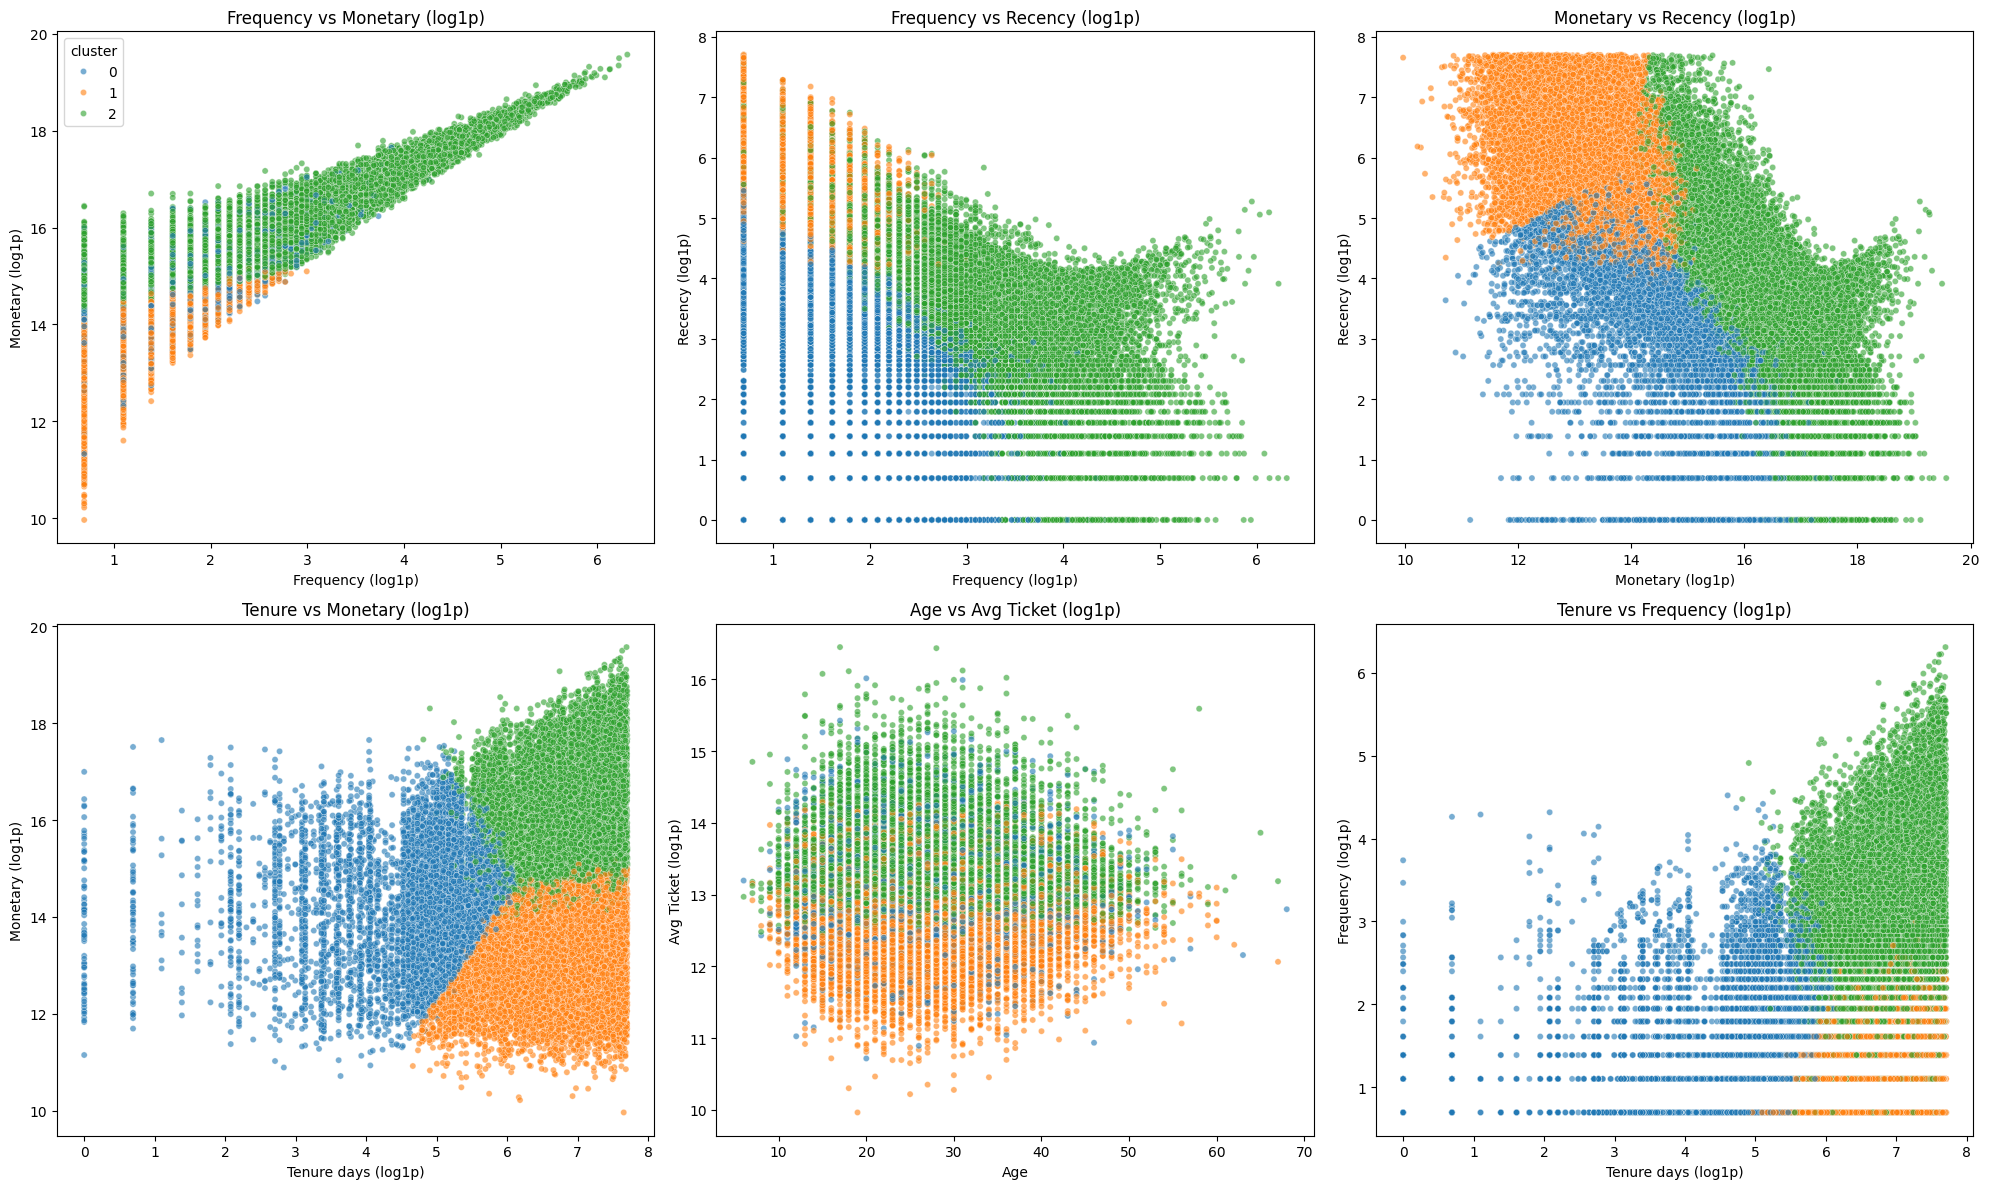

In [29]:
customer_segments_full = customer_segments[['customer_id', 'cluster']].merge(
    customers_df[['customer_id', 'age', 'tenure_days', 'avg_ticket', 'Recency', 'Frequency', 'Monetary', 'gender', 'device_type', 'home_location']],
    on='customer_id', how='left'
) # Resumen por cluster con variables originales (escala interpretable)

def mode_or_unknown(s): # Función para obtener la moda de una serie, devolviendo 'Unknown' si no hay moda o si es NaN
    m = s.mode(dropna=True)
    return m.iloc[0] if not m.empty else 'Unknown'

cluster_profile = (
    customer_segments_full
    .groupby('cluster')
    .agg(
        n_customers=('customer_id', 'count'), # Número de clientes en cada cluster
        avg_age=('age', 'mean'), # Edad promedio por cluster
        avg_tenure=('tenure_days', 'mean'), # Antigüedad promedio por cluster
        avg_ticket=('avg_ticket', 'mean'), # Ticket promedio por cluster
        avg_recency=('Recency', 'mean'), # Recencia promedio por cluster
        avg_frequency=('Frequency', 'mean'), # Frecuencia promedio por cluster
        avg_monetary=('Monetary', 'mean'), # Valor monetario promedio por cluster
        main_device=('device_type', mode_or_unknown), # Dispositivo principal por cluster
        main_location=('home_location', mode_or_unknown) # Ubicación principal por cluster
    )
    .sort_values('avg_monetary', ascending=False)
    .round(2)
)
print("=== Perfil de cada cluster K-Prototypes ===")
display(cluster_profile)

rfm_vs_kproto = pd.crosstab( # Crosstab con clusters RFM (K-Means)
    customer_segments_full['cluster'],
    rfm_clustered.loc[customer_segments_full['customer_id'], 'Cluster'].values,
    colnames=['RFM_Cluster'],
    normalize='index'
).round(3)
print("\n=== Relación entre clusters K-Prototypes y clusters RFM (K-Means) ===")
display(rfm_vs_kproto)


print("\n=== Distribución de device_type por cluster ===") # Distribución por dispositivo y género dentro de cada cluster
display(pd.crosstab(customer_segments_full['cluster'], customer_segments_full['device_type'], normalize='index').round(3))

print("\n=== Distribución de gender por cluster ===")
display(pd.crosstab(customer_segments_full['cluster'], customer_segments_full['gender'], normalize='index').round(3))

plot_df = customer_segments_full.copy()
plot_df['Frequency_log'] = np.log1p(plot_df['Frequency'])
plot_df['Monetary_log'] = np.log1p(plot_df['Monetary'])
plot_df['Recency_log'] = np.log1p(plot_df['Recency'])
plot_df['tenure_log'] = np.log1p(plot_df['tenure_days'])
plot_df['avg_ticket_log'] = np.log1p(plot_df['avg_ticket'])

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1) Frequency vs Monetary
sns.scatterplot(data=plot_df, x='Frequency_log', y='Monetary_log', hue='cluster',
                palette='tab10', alpha=0.6, s=20, ax=axes[0, 0])
axes[0, 0].set_title('Frequency vs Monetary (log1p)')
axes[0, 0].set_xlabel('Frequency (log1p)')
axes[0, 0].set_ylabel('Monetary (log1p)')

# 2) Frequency vs Recency
sns.scatterplot(data=plot_df, x='Frequency_log', y='Recency_log', hue='cluster',
                palette='tab10', alpha=0.6, s=20, ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Frequency vs Recency (log1p)')
axes[0, 1].set_xlabel('Frequency (log1p)')
axes[0, 1].set_ylabel('Recency (log1p)')

# 3) Monetary vs Recency
sns.scatterplot(data=plot_df, x='Monetary_log', y='Recency_log', hue='cluster',
                palette='tab10', alpha=0.6, s=20, ax=axes[0, 2], legend=False)
axes[0, 2].set_title('Monetary vs Recency (log1p)')
axes[0, 2].set_xlabel('Monetary (log1p)')
axes[0, 2].set_ylabel('Recency (log1p)')

# 4) Tenure vs Monetary
sns.scatterplot(data=plot_df, x='tenure_log', y='Monetary_log', hue='cluster',
                palette='tab10', alpha=0.6, s=20, ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Tenure vs Monetary (log1p)')
axes[1, 0].set_xlabel('Tenure days (log1p)')
axes[1, 0].set_ylabel('Monetary (log1p)')

# 5) Age vs Avg Ticket
sns.scatterplot(data=plot_df, x='age', y='avg_ticket_log', hue='cluster',
                palette='tab10', alpha=0.6, s=20, ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Age vs Avg Ticket (log1p)')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Avg Ticket (log1p)')

# 6) Tenure vs Frequency
sns.scatterplot(data=plot_df, x='tenure_log', y='Frequency_log', hue='cluster',
                palette='tab10', alpha=0.6, s=20, ax=axes[1, 2], legend=False)
axes[1, 2].set_title('Tenure vs Frequency (log1p)')
axes[1, 2].set_xlabel('Tenure days (log1p)')
axes[1, 2].set_ylabel('Frequency (log1p)')

plt.tight_layout()
plt.show()

## 5. Clustering Geográfico con DBSCAN

#### PREGUNTA 8:
* Analiza los datos de geolocalización de los lugares de residencia y realiza una segmentación de clientes en base a dicha información utilizando DBSCAN

#### RESPUESTA:

Para la segmentación geográfica se usan las coordenadas de residencia (home_location_lat, home_location_long) y DBSCAN con distancia **haversine**, que es apropiada para coordenadas sobre la superficie terrestre. Se probaron varios valores de eps y min_samples sobre una muestra, y la configuración seleccionada fue eps = 75 km y min_samples = 120, por ofrecer un buen equilibrio entre número de clusters y nivel de ruido.

Con esa configuración, el modelo detectó **15 clusters geográficos** y dejó solo **2.95%** de observaciones como ruido. El cluster principal concentra **72,968 clientes** y está dominado por la zona de **Jakarta Raya / eje de Java**, mientras que otro cluster importante agrupa **16,654 clientes** en torno a **Kalimantan**. Además, aparecen clusters más pequeños en Sulawesi, Maluku, Papua y otras islas, lo que confirma que la residencia de los clientes forma concentraciones espaciales reales y no una distribución uniforme.

Total clientes: 100000

Nulos por columna:
customer_id           0
home_location         0
home_location_lat     0
home_location_long    0
dtype: int64

% con coordenadas válidas: 100.0%

=== Estadísticas descriptivas de coordenadas ===


,home_location_lat,home_location_long
count,100000.0000,100000.0000
mean,-5.1064,110.9361
std,3.0882,6.3434
min,-10.8450,95.2753
25%,-7.3726,106.8606
50%,-6.2401,110.1620
75%,-3.0923,113.1712
max,5.8184,140.9931



=== Top 10 ubicaciones por frecuencia ===


,n_clientes
home_location,
Jakarta Raya,18715
Jawa Barat,11486
Jawa Tengah,10960
Jawa Timur,9953
Yogyakarta,7849
Kalimantan Barat,5603
Lampung,5426
Kalimantan Selatan,4229
Kalimantan Tengah,4091


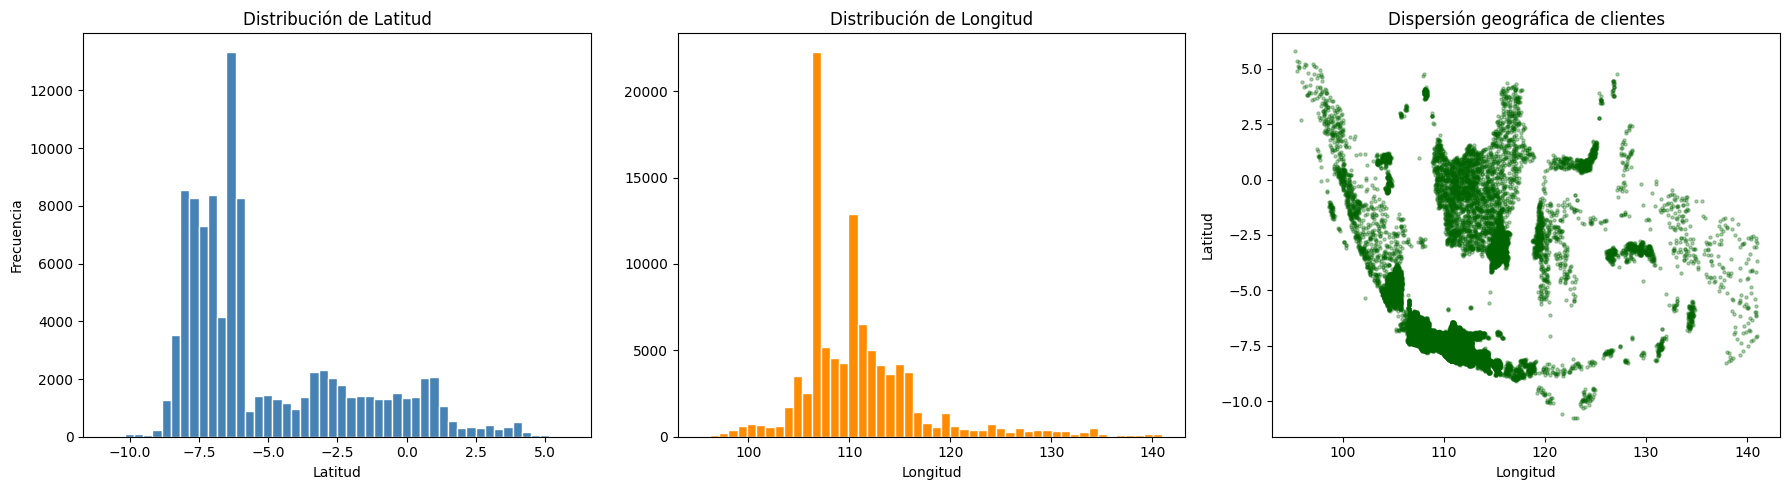


Clientes fuera del rango geográfico esperado (Indonesia): 0


In [30]:
# --- EDA de datos geoespaciales ---
geo_raw = customers[['customer_id', 'home_location', 'home_location_lat', 'home_location_long']].copy()

# Nulos y dimensiones
print(f"Total clientes: {len(geo_raw)}")
print(f"\nNulos por columna:")
print(geo_raw.isnull().sum())
print(f"\n% con coordenadas válidas: {geo_raw[['home_location_lat','home_location_long']].dropna().shape[0] / len(geo_raw) * 100:.1f}%")

# Estadísticas descriptivas de lat/long
print("\n=== Estadísticas descriptivas de coordenadas ===")
display(geo_raw[['home_location_lat', 'home_location_long']].describe().round(4))

# Distribución de home_location (top 10)
print("\n=== Top 10 ubicaciones por frecuencia ===")
display(geo_raw['home_location'].value_counts().head(10).to_frame('n_clientes'))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Histograma latitud
axes[0].hist(geo_raw['home_location_lat'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Latitud')
axes[0].set_xlabel('Latitud')
axes[0].set_ylabel('Frecuencia')

# 2) Histograma longitud
axes[1].hist(geo_raw['home_location_long'].dropna(), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución de Longitud')
axes[1].set_xlabel('Longitud')

# 3) Scatter geográfico (muestra)
sample = geo_raw.dropna(subset=['home_location_lat', 'home_location_long']).sample(min(20000, len(geo_raw)), random_state=42)
axes[2].scatter(sample['home_location_long'], sample['home_location_lat'], s=5, alpha=0.3, c='darkgreen')
axes[2].set_title('Dispersión geográfica de clientes')
axes[2].set_xlabel('Longitud')
axes[2].set_ylabel('Latitud')

plt.tight_layout()
plt.show()

# Detección de posibles outliers geográficos (fuera del archipiélago indonesio aprox.)
lat_range = (-11, 6)
long_range = (95, 141)
outliers_geo = geo_raw[
    (geo_raw['home_location_lat'] < lat_range[0]) | (geo_raw['home_location_lat'] > lat_range[1]) |
    (geo_raw['home_location_long'] < long_range[0]) | (geo_raw['home_location_long'] > long_range[1])
].dropna(subset=['home_location_lat', 'home_location_long'])
print(f"\nClientes fuera del rango geográfico esperado (Indonesia): {len(outliers_geo)}")
if len(outliers_geo) > 0:
    display(outliers_geo.head(10))

In [31]:
# Segmentacion geografica con DBSCAN
geo_df = customers[['home_location_lat', 'home_location_long']].dropna().copy()
coords_rad = np.radians(geo_df) # Conversión a radianes para DBSCAN con métrica haversine
 
candidate_params = [ # Diferentes combinaciones de parámetros para evaluar en DBSCAN
    {'eps_km': 25, 'min_samples': 80},
    {'eps_km': 50, 'min_samples': 100},
    {'eps_km': 75, 'min_samples': 120}
 ]

param_results = []
for params in candidate_params:
    model = DBSCAN(
        eps=params['eps_km'] / 6371.0088, # Conversión de kms a radianes usando el radio de la Tierra
        min_samples=params['min_samples'], # Número mínimo de puntos para formar un cluster
        metric='haversine', # Métrica de distancia geográfica basada en la fórmula de Haversine
        algorithm='ball_tree' # Algoritmo eficiente para datos geoespaciales
    )
    labels = model.fit_predict(coords_rad) 
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0) # Número de clusters detectados, excluyendo el ruido (-1)
    noise_rate = float((labels == -1).mean()) # Porcentaje de puntos considerados ruido
    param_results.append({
        'eps_km': params['eps_km'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'noise_rate': round(noise_rate, 4)
    })

param_results = pd.DataFrame(param_results)
display(param_results)

valid_params = param_results[(param_results['n_clusters'] >= 3) & (param_results['n_clusters'] <= 25)] # Filtramos para quedarnos con combinaciones que den un número razonable de clusters geográficos (entre 3 y 25)
best_params = valid_params.sort_values(['noise_rate', 'n_clusters']).head(1) # Elegimos la combinación con menor porcentaje de ruido y un número adecuado de clusters. 
if best_params.empty: # Si no hay combinaciones válidas, se elige la que tenga el menor ruido sin importar el número de clusters.
    best_params = param_results.sort_values(['noise_rate', 'n_clusters']).head(1)

best_eps_km = float(best_params.iloc[0]['eps_km']) 
best_min_samples = int(best_params.iloc[0]['min_samples']) 
print(f'Parametros elegidos: eps={best_eps_km} km, min_samples={best_min_samples}')

geo_model = DBSCAN(
    eps=best_eps_km / 6371.0088,
    min_samples=best_min_samples,
    metric='haversine',
    algorithm='ball_tree'
 )

geo_df['geo_cluster'] = geo_model.fit_predict(coords_rad) # Entrenamiento final de DBSCAN con los mejores parámetros encontrados para segmentación geográfica

n_geo_clusters = len(set(geo_df['geo_cluster'])) - (1 if -1 in geo_df['geo_cluster'].values else 0)
noise_share = (geo_df['geo_cluster'] == -1).mean()
print(f'Clusters geograficos detectados: {n_geo_clusters}')
print(f'Porcentaje de ruido: {noise_share:.2%}')

# Visualización sobre mapa OpenStreetMap con plotly
map_sample = geo_df.sample(min(15000, len(geo_df)), random_state=42).copy()
map_sample['geo_cluster_str'] = map_sample['geo_cluster'].astype(str)

fig = px.scatter_mapbox(
    map_sample,
    lat='home_location_lat',
    lon='home_location_long',
    color='geo_cluster_str',
    color_discrete_sequence=px.colors.qualitative.Dark24,
    opacity=0.6,
    size_max=8,
    zoom=4,
    center={'lat': -5.0, 'lon': 117.0},
    title='DBSCAN sobre ubicación de residencia (OpenStreetMap)',
    labels={'geo_cluster_str': 'Geo Cluster'}
)
fig.update_layout(
    mapbox_style='open-street-map',
    height=600,
    margin=dict(l=0, r=0, t=40, b=0)
)
fig.update_traces(marker=dict(size=5))
fig.show()

,eps_km,min_samples,n_clusters,noise_rate
0,25,80,25,0.1694
1,50,100,15,0.0500
2,75,120,15,0.0295


Parametros elegidos: eps=75.0 km, min_samples=120
Clusters geograficos detectados: 15
Porcentaje de ruido: 2.95%


#### PREGUNTA 9:
* ¿Qué insights se derivan de esta segmentación y qué acciones concretas propondrías?

#### RESPUESTA:

La segmentación geográfica con DBSCAN (eps=75 km, min_samples=120, métrica haversine) detectó **15 clusters geográficos** con solo un **2.95% de ruido** (≈2,950 clientes no asignados a ningún cluster). Esto confirma que la distribución de clientes no es uniforme, sino que forma concentraciones espaciales bien definidas sobre el archipiélago indonesio.

**Insights principales**:

1. **Concentración masiva en Java (cluster dominante, ~73,000 clientes)**: agrupa Jakarta Raya (18,715 clientes), Jawa Barat (11,486), Jawa Tengah (10,960), Jawa Timur (9,953) y Yogyakarta (7,849). Este corredor representa más del **59% de toda la base de clientes** y es el motor económico de la plataforma.

2. **Kalimantan como segundo polo (~16,600 clientes)**: Kalimantan Barat (5,603), Kalimantan Selatan (4,229), Kalimantan Tengah (4,091) y Kalimantan Timur (2,729) forman un bloque relevante con potencial de crecimiento regional.

3. **Mercados periféricos fragmentados**: Sulawesi, Sumatra (Lampung con 5,426 clientes), Maluku y Papua generan clusters más pequeños y dispersos, reflejando mercados menos maduros con menor densidad.

4. **Muy bajo ruido (2.95%)**: la inmensa mayoría de clientes pertenece a concentraciones geográficas identificables, lo que valida que la geolocalización aporta valor real como dimensión de segmentación independiente del comportamiento transaccional.

5. **Sin outliers geográficos**: en el EDA previo se verificó que todos los clientes se ubican dentro del rango del archipiélago indonesio (latitud: -10.8 a 5.8, longitud: 95.3 a 141.0), por lo que no fue necesario eliminar datos atípicos antes de aplicar DBSCAN.

6. **Los 3 clusters más grandes concentran la gran mayoría de la base**, lo que indica una distribución geográfica muy desigual: pocas regiones acaparan la mayor parte de los clientes, mientras muchas regiones tienen presencia marginal.

**Acciones concretas recomendadas**:

1. **Java/Jakarta (cluster dominante)**: invertir en logística de última milla (entrega en 24h), almacenes locales, campañas de marketing intensivas y puntos de recogida. La masa crítica de >73,000 clientes justifica operaciones premium y promociones agresivas.

2. **Kalimantan (segundo polo)**: desarrollar partnerships logísticos regionales, campañas de expansión dirigidas y optimización de rutas de envío. Con ~16,600 clientes la densidad es suficiente para estrategias diferenciadas.

3. **Clusters periféricos (Sulawesi, Papua, Lampung, etc.)**: adaptar la propuesta con envíos agrupados, plazos de entrega más amplios y promociones que compensen costes logísticos elevados. Evaluar marketplaces locales como canal alternativo.

4. **Clientes ruido (~2,950)**: estos clientes aislados geográficamente requieren tratamiento individualizado — atendibles solo vía courier nacional o dropshipping; no justifican infraestructura dedicada.

5. **Segmentación cruzada con RFM y K-Prototypes**: combinar los clusters geográficos con los segmentos de valor permite estrategias hiperlocales. Por ejemplo:
   - Clientes de alto valor (K-Prototypes cluster 2) en Jakarta → programa VIP con entrega express y beneficios exclusivos.
   - Clientes inactivos (K-Prototypes cluster 1) en Kalimantan → reactivación con descuento en envío regional.
   - Clientes recientes con potencial (K-Prototypes cluster 0) en zonas periféricas → onboarding acelerado con envío gratuito en primeras compras.

In [36]:
# Enriquecer geo_df con customer_id y home_location (mismo indice que customers)
geo_enriched = customers[['customer_id', 'home_location', 'home_location_lat', 'home_location_long']].dropna(subset=['home_location_lat', 'home_location_long']).copy()
geo_enriched['geo_cluster'] = geo_df['geo_cluster'].values

# Merge con metricas transaccionales
geo_business = geo_enriched.merge(
    customers_df[['customer_id', 'Frequency', 'Monetary', 'avg_ticket', 'Recency']],
    on='customer_id',
    how='left'
)

# Resumen por cluster geografico
geo_business_summary = (
    geo_business
    .groupby('geo_cluster')
    .agg(
        n_customers=('customer_id', 'count'),
        avg_frequency=('Frequency', 'mean'),
        avg_ticket=('avg_ticket', 'mean'),
        avg_monetary=('Monetary', 'mean'),
        avg_recency=('Recency', 'mean'),
        main_location=('home_location', lambda s: s.mode().iloc[0] if not s.mode().empty else 'Unknown')
    )
    .sort_values('n_customers', ascending=False)
    .round(2)
)

print("=== Resumen de negocio por cluster geografico (Top 10) ===")
display(geo_business_summary.head(10))

print(f"\n=== Distribucion de clientes ===")
print(f"Total clientes geolocalizados: {len(geo_business):,}")
print(f"Clusters detectados: {n_geo_clusters}")
print(f"Ruido (sin cluster): {(geo_business['geo_cluster'] == -1).sum():,} ({noise_share:.2%})")
top3 = geo_business_summary.head(3)['n_customers'].sum()
print(f"\nTop 3 clusters concentran: {top3 / len(geo_business) * 100:.1f}% de los clientes")

=== Resumen de negocio por cluster geografico (Top 10) ===


,n_customers,avg_frequency,avg_ticket,avg_monetary,avg_recency,main_location
geo_cluster,,,,,,
0,72968,16.30,539223.56,8825629.84,297.00,Jakarta Raya
1,16654,16.07,541269.15,8675353.44,305.14,Kalimantan Barat
-1,2951,16.33,539917.36,8776478.30,309.76,Papua
4,2119,15.23,533414.16,8269779.88,318.32,Sulawesi Barat
3,1558,16.53,530379.81,8902024.42,311.44,Sulawesi Utara
5,1468,15.88,580856.22,8715631.82,303.01,Maluku
6,424,17.42,483767.51,9020245.64,286.59,Maluku
8,412,14.73,570183.08,8102371.98,277.72,Kepulauan Riau
10,285,17.52,524959.25,9616529.08,328.34,Papua Barat



=== Distribucion de clientes ===
Total clientes geolocalizados: 100,000
Clusters detectados: 15
Ruido (sin cluster): 2,951 (2.95%)

Top 3 clusters concentran: 92.6% de los clientes


---

## Declaración de uso de IA Generativa

En la elaboración de este trabajo se ha utilizado IA generativa (GitHub Copilot / ChatGPT) como herramienta de apoyo en los siguientes aspectos:

1. **Mejora de redacción**: se ha empleado para mejorar la claridad, estructura y fluidez de los textos explicativos en las celdas markdown, así como para pulir la redacción de las respuestas a las preguntas del enunciado.
2. **Comentarios de código**: se ha utilizado para mejorar y homogeneizar los comentarios dentro del código Python, haciéndolos más descriptivos y coherentes.
3. **Resolución de errores puntuales**: en casos concretos donde el código generaba errores de ejecución, se ha recurrido a la IA para diagnosticar y corregir dichos errores (p.ej., incompatibilidades de tipos de datos, variables no definidas o problemas con la visualización).

En todos los casos, el análisis, la toma de decisiones metodológicas, la interpretación de resultados y las conclusiones de negocio son responsabilidad del autor.